# DiffPIR / DPS / Plug-and-Play comparison

This notebook is a unified playground for comparing:

- DiffPIR
- DPS variants (`DPS_y0`, `DPS_yt`)
- Plug-and-play methods with other priors (e.g. DRUNet)

across the three tasks:

- Super-resolution (SISR)
- Deblurring
- Inpainting

In [1]:
import os
from pathlib import Path
from typing import Dict, List

import numpy as np
import matplotlib.pyplot as plt

from experiments.common import MethodConfig, RunResult, run_experiment, load_image_paths
from experiments import pnp_priors
from experiments import sr_methods, deblur_methods, inpaint_methods


In [2]:
# Registry of available per-image methods for each task.

def get_sr_methods():
    return {
        "diffpir": sr_methods.run_diffpir_sr,
        "dps_y0": lambda img, cfg: sr_methods.run_dps_sr(img, cfg, mode="DPS_y0"),
        "dps_yt": lambda img, cfg: sr_methods.run_dps_sr(img, cfg, mode="DPS_yt"),
        # Enable this once you implement run_pnp_drunet_sr
        "pnp_drunet": sr_methods.run_pnp_drunet_sr,
    }


def get_deblur_methods():
    return {
        "diffpir": deblur_methods.run_diffpir_deblur,
        "dps_y0": lambda img, cfg: deblur_methods.run_dps_deblur(img, cfg, mode="DPS_y0"),
        "dps_yt": lambda img, cfg: deblur_methods.run_dps_deblur(img, cfg, mode="DPS_yt"),
        "pnp_drunet": deblur_methods.run_pnp_drunet_deblur,
    }


def get_inpaint_methods():
    return {
        "diffpir": inpaint_methods.run_diffpir_inpaint,
        "dps_y0": lambda img, cfg: inpaint_methods.run_dps_inpaint(img, cfg, mode="DPS_y0"),
        "dps_yt": lambda img, cfg: inpaint_methods.run_dps_inpaint(img, cfg, mode="DPS_yt"),
        "pnp_drunet": inpaint_methods.run_pnp_drunet_inpaint,
    }


METHOD_REGISTRY = {
    "sr": get_sr_methods(),
    "deblur": get_deblur_methods(),
    "inpaint": get_inpaint_methods(),
}


def _default_method_config(task: str, name: str) -> MethodConfig:
    """Create a simple MethodConfig for a given task/method name."""

    if name.startswith("dps_"):
        generate_mode = name.upper()  # "DPS_Y0" / "DPS_YT" variants
    elif name == "diffpir":
        generate_mode = "DiffPIR"
    else:
        generate_mode = name  # e.g. "pnp_drunet"

    return MethodConfig.load_from_yaml(
        os.path.join("configs", f"{task}.yaml"),
        name
    )


def compare_task(
    task: str,
    testset_root: str,
    methods: List[str],
) -> Dict[str, RunResult]:
    """Run all selected methods for a given task over a dataset.

    Returns a dict mapping method name -> RunResult.
    """

    image_paths = load_image_paths(testset_root)
    task_methods = METHOD_REGISTRY[task]
    results: Dict[str, RunResult] = {}

    for name in methods:
        if name not in task_methods:
            raise ValueError(f"Unknown method '{name}' for task '{task}'")
        method_fn = task_methods[name]
        cfg = _default_method_config(task=task, name=name)
        print(cfg)
        run_result = run_experiment(
            method_config=cfg,
            image_paths=image_paths,
            method_fn=method_fn,
            output_root=None,
        )
        results[name] = run_result
    return results


def plot_metric_bar(results: Dict[str, RunResult], metric: str = "average_psnr", title: str = ""):
    """Plot a bar chart of a given aggregate metric for each method."""

    methods = list(results.keys())
    values = [float(getattr(results[m], metric)) for m in methods]

    plt.figure(figsize=(6, 4))
    plt.bar(methods, values)
    plt.ylabel(metric)
    plt.title(title or metric)
    plt.grid(axis="y", alpha=0.3)
    plt.show()

# show resulting images
def show_results(results: Dict[str, RunResult]) -> None:
    """Display in a single row the first image of each method alongside the ground truth."""

    # Pick the first image name that appears in the first run's results
    first_run = next(iter(results.values()))
    first_img_name = next(iter(first_run.image_results))

    n_methods = len(results)
    fig, axes = plt.subplots(1, n_methods + 1, figsize=(4 * (n_methods + 1), 4))

    # Ground truth — image_path on ImageResult always points to the sharp GT
    gt_path = first_run.image_results[first_img_name].image_path
    axes[0].imshow(plt.imread(gt_path))
    axes[0].set_title(f"Ground Truth\n{first_img_name}")
    axes[0].axis("off")

    for ax, (method_name, run_result) in zip(axes[1:], results.items()):
        img_result = run_result.image_results.get(first_img_name)
        if img_result is None:
            ax.text(0.5, 0.5, "No result", ha="center", va="center", transform=ax.transAxes)
            ax.axis("off")
            continue

        if img_result.output_path and os.path.exists(img_result.output_path):
            ax.imshow(plt.imread(img_result.output_path))
        else:
            ax.text(
                0.5, 0.5,
                f"Image not found\n{img_result.output_path}",
                ha="center", va="center", transform=ax.transAxes, fontsize=8,
            )

        title = f"{method_name}\nPSNR: {img_result.psnr:.2f} dB"
        if img_result.lpips is not None:
            title += f"\nLPIPS: {img_result.lpips:.4f}"
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:
# Hyper parameters tuning
# Let's try to find best lambda for deblurring
def best_lambda_deblur():
    # Load the deblur config
    config = MethodConfig.load_from_yaml(os.path.join("configs", "deblur.yaml"))
    best_lambda = None
    best_psnr = 0
    # Run the deblur experiment for a range of lambdas
    for lambda_ in np.arange(1, 5):
        deblur_results = compare_task(
            task="deblur",
            testset_root="testsets/demo_test",
            methods=["diffpir"],
            sf=1,
            lambda_=lambda_,
        )
        # Get the average PSNR of the deblur results
        average_psnr = deblur_results["diffpir"].average_psnr
        print(f"Lambda: {lambda_}, Average PSNR: {average_psnr}")
        if average_psnr > best_psnr:
            best_psnr = average_psnr
            best_lambda = lambda_
    print(f"Best lambda: {best_lambda}, Best PSNR: {best_psnr}")
    return best_lambda, best_psnr

best_lambda_deblur()

[2026-03-12 10:37:36,620][diffpir_deblur.69037][INFO] Starting DiffPIR deblurring | img=69037 | lambda=2.000 | zeta=0.250 | noise=0.0500 | model=diffusion_ffhq_10m


Loading diffpir from configs/deblur.yaml
MethodConfig(task='deblur', generate_mode='DiffPIR', lambda_=2, zeta=0.25, sf=1, extra={'seed': 42, 'noise_level_img': 0.05, 'noise_level_model': 'noise_level_img', 'model_name': 'diffusion_ffhq_10m', 'testset_name': 'demo_test', 'num_train_timesteps': 1000, 'iter_num': 100, 'iter_num_U': 1, 'batch_size': 16, 'save_L': True, 'save_E': True, 'sub_1_analytic': True, 'log_process': False, 'ddim_sample': False, 'model_output_type': 'pred_xstart', 'skip_type': 'quad', 'eta': 0, 'guidance_scale': 1.0, 'n_channels': 3, 'cwd': '', 'calc_LPIPS': True, 'beta_start': 0.0001, 'beta_end': 0.02, 'noise_init_img': 'max', 'skip_noise_model_t': False, 'use_DIY_kernel': True, 'blur_mode': 'Gaussian', 'kernel_size': 61})
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/Users/armandblin/Desktop/DiffPIR/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/armandblin/Desktop/DiffPIR/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
[2026-03-12 10:37:37,960][diffpir_deblur.69037][INFO] Loading ground-truth image from testsets/demo_test/69037.png
[2026-03-12 10:37:37,976][diffpir_deblur.69037][INFO] Blur kernel: mode=Gaussian | kernel_size=61 | kernel_std≈3.000
[2026-03-12 10:37:37,976][diffpir_deblur.69037][INFO] Applying blur and AWGN (σ≈0.0500)


Loading model from: /Users/armandblin/Desktop/DiffPIR/.venv/lib/python3.11/site-packages/lpips/weights/v0.1/vgg.pth


[2026-03-12 10:37:38,552][diffpir_deblur.69037][INFO] Starting reverse diffusion (100 steps, skip_type=quad)
DiffPIR Deblurring: 100%|██████████| 100/100 [01:03<00:00,  1.59it/s]
[2026-03-12 10:38:41,575][diffpir_deblur.69037][INFO] Reverse diffusion finished for 69037
[2026-03-12 10:38:41,727][diffpir_deblur.69037][INFO] Results | img=69037 | PSNR=22.371 dB | LPIPS=0.3409
[2026-03-12 10:38:41,732][diffpir_deblur.69037][INFO] Saved restored image to outputs/diffpir_deblur/69037_diffpir.png
[2026-03-12 10:38:41,736][diffpir_deblur.69037][INFO] Saved LR image to outputs/diffpir_deblur/69037_LR.png
[2026-03-12 10:38:41,769][pnp_deblur.69037][INFO] Starting PnP deblurring | img=69037 | denoiser=drunet | iters=8 | step=1.000 | blur=Gaussian | noise=0.0500
[2026-03-12 10:38:41,769][pnp_deblur.69037][INFO] Loading ground-truth image from testsets/demo_test/69037.png
[2026-03-12 10:38:41,773][pnp_deblur.69037][INFO] Blur kernel: mode=Gaussian | kernel_size=61 | kernel_std≈3.000
[2026-03-12 10:

Loading pnp_drunet from configs/deblur.yaml
MethodConfig(task='deblur', generate_mode='pnp_drunet', lambda_=1.0, zeta=0.0, sf=1, extra={'name': 'pnp_drunet', 'noise_level_img': 0.05, 'noise_level_model': 'noise_level_img', 'blur_mode': 'Gaussian', 'kernel_size': 61, 'kernel_std': 3.0, 'denoiser': 'drunet', 'num_iters': 8, 'step_size': 1.0, 'data_weight': 1.0, 'denoiser_sigma': 0.05, 'sigma_schedule': 'constant', 'gaussian_kernel_size': 5, 'gaussian_sigma': 1.0, 'drunet_weights_path': '', 'calc_LPIPS': True, 'save_L': True, 'save_E': True, 'clamp': True, 'output_root': 'outputs'})


/Users/armandblin/Desktop/DiffPIR/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[2026-03-12 10:38:42,918][pnp_deblur.69037][INFO] Using DRUNet denoiser from 
PnP Deblurring: 100%|██████████| 8/8 [00:03<00:00,  2.44it/s]
/Users/armandblin/Desktop/DiffPIR/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/armandblin/Desktop/DiffPIR/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use 

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


[2026-03-12 10:38:46,900][pnp_deblur.69037][INFO] Results | img=69037 | PSNR=22.636 dB | LPIPS=0.4818
[2026-03-12 10:38:46,904][pnp_deblur.69037][INFO] Saved restored image to outputs/pnp_deblur/69037_pnp_drunet.png
[2026-03-12 10:38:46,908][pnp_deblur.69037][INFO] Saved LR image to outputs/pnp_deblur/69037_LR.png


Loading model from: /Users/armandblin/Desktop/DiffPIR/.venv/lib/python3.11/site-packages/lpips/weights/v0.1/vgg.pth


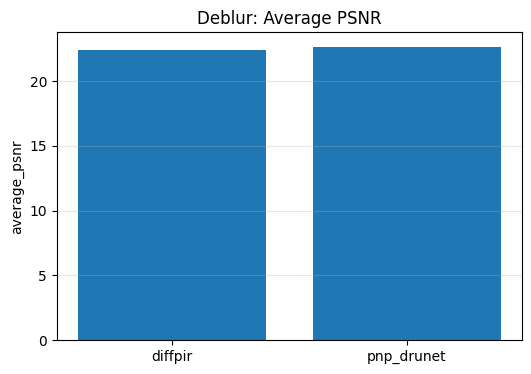

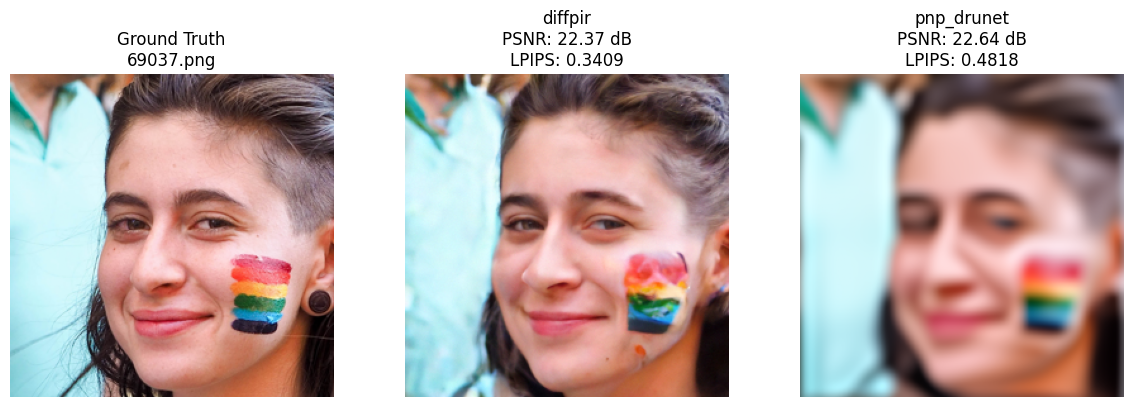

In [4]:
# Deblurring comparison
deblur_results = compare_task(
    task="deblur",
    testset_root="testsets/demo_test",
    methods=["diffpir", "pnp_drunet"],  # diffpir, "dps_y0", "dps_yt"
)
plot_metric_bar(deblur_results, metric="average_psnr", title="Deblur: Average PSNR")
show_results(deblur_results)

[2026-03-12 11:06:05,296][diffpir_sr.69037][INFO] Starting DiffPIR SR | img=69037 | sf=4 | lambda=1.000 | zeta=0.100 | noise=0.0500 | model=diffusion_ffhq_10m | mode=blur


Loading diffpir from configs/sr.yaml
MethodConfig(task='sr', generate_mode='DiffPIR', lambda_=1.0, zeta=0.1, sf=4, extra={'seed': 42, 'noise_level_img': 0.05, 'noise_level_model': 0.05, 'model_name': 'diffusion_ffhq_10m', 'testset_name': 'demo_test', 'num_train_timesteps': 1000, 'iter_num': 100, 'iter_num_U': 1, 'batch_size': 16, 'save_L': True, 'save_E': True, 'sub_1_analytic': True, 'log_process': False, 'ddim_sample': False, 'model_output_type': 'pred_xstart', 'skip_type': 'quad', 'eta': 0.0, 'guidance_scale': 1.0, 'n_channels': 3, 'cwd': '', 'calc_LPIPS': True, 'beta_start': 0.0001, 'beta_end': 0.02, 'sr_mode': 'blur', 'classical_degradation': False, 'inIter': 1, 'gamma': 0.01})
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


[2026-03-12 11:06:07,193][diffpir_sr.69037][INFO] Loaded SR kernel | classical=False | sf=4 | shape=(25, 25)
[2026-03-12 11:06:07,197][diffpir_sr.69037][INFO] Loading ground-truth image from testsets/demo_test/69037.png
[2026-03-12 11:06:07,211][diffpir_sr.69037][INFO] SR observation: mode=blur | sf=4 | LR size=(64, 64) | noise=0.0500
[2026-03-12 11:06:07,246][diffpir_sr.69037][INFO] Starting reverse diffusion (100 steps, skip_type=quad)


Loading model from: /Users/armandblin/Desktop/DiffPIR/.venv/lib/python3.11/site-packages/lpips/weights/v0.1/vgg.pth


DiffPIR SR x4: 100%|██████████| 100/100 [01:48<00:00,  1.09s/it]
[2026-03-12 11:07:55,752][diffpir_sr.69037][INFO] Reverse diffusion finished for 69037
[2026-03-12 11:07:56,122][diffpir_sr.69037][INFO] Results | img=69037 | PSNR=23.279 dB | PSNR-Y=26.122 dB | LPIPS=0.4721
[2026-03-12 11:07:56,131][diffpir_sr.69037][INFO] Saved SR image to outputs/diffpir_sr/69037_x4_diffpir.png
[2026-03-12 11:07:56,133][diffpir_sr.69037][INFO] Saved LR image to outputs/diffpir_sr/69037_x4_LR.png
[2026-03-12 11:07:56,189][diffpir_sr.69133][INFO] Starting DiffPIR SR | img=69133 | sf=4 | lambda=1.000 | zeta=0.100 | noise=0.0500 | model=diffusion_ffhq_10m | mode=blur


...

DiffPIR SR x4: 100%|██████████| 100/100 [01:47<00:00,  1.08s/it]
[2026-03-12 11:13:12,139][diffpir_sr.69887][INFO] Reverse diffusion finished for 69887
[2026-03-12 11:13:12,389][diffpir_sr.69887][INFO] Results | img=69887 | PSNR=23.691 dB | PSNR-Y=26.728 dB | LPIPS=0.4248
[2026-03-12 11:13:12,399][diffpir_sr.69887][INFO] Saved SR image to outputs/diffpir_sr/69887_x4_diffpir.png
[2026-03-12 11:13:12,402][diffpir_sr.69887][INFO] Saved LR image to outputs/diffpir_sr/69887_x4_LR.png
[2026-03-12 11:13:12,435][diffpir_sr.69929][INFO] Starting DiffPIR SR | img=69929 | sf=4 | lambda=1.000 | zeta=0.100 | noise=0.0500 | model=diffusion_ffhq_10m | mode=blur


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


[2026-03-12 11:13:14,129][diffpir_sr.69929][INFO] Loaded SR kernel | classical=False | sf=4 | shape=(25, 25)
[2026-03-12 11:13:14,131][diffpir_sr.69929][INFO] Loading ground-truth image from testsets/demo_test/69929.png
[2026-03-12 11:13:14,155][diffpir_sr.69929][INFO] SR observation: mode=blur | sf=4 | LR size=(64, 64) | noise=0.0500
[2026-03-12 11:13:14,173][diffpir_sr.69929][INFO] Starting reverse diffusion (100 steps, skip_type=quad)


Loading model from: /Users/armandblin/Desktop/DiffPIR/.venv/lib/python3.11/site-packages/lpips/weights/v0.1/vgg.pth


DiffPIR SR x4: 100%|██████████| 100/100 [01:43<00:00,  1.03s/it]
[2026-03-12 11:14:57,663][diffpir_sr.69929][INFO] Reverse diffusion finished for 69929
[2026-03-12 11:14:58,047][diffpir_sr.69929][INFO] Results | img=69929 | PSNR=23.452 dB | PSNR-Y=26.155 dB | LPIPS=0.5030
[2026-03-12 11:14:58,055][diffpir_sr.69929][INFO] Saved SR image to outputs/diffpir_sr/69929_x4_diffpir.png
[2026-03-12 11:14:58,058][diffpir_sr.69929][INFO] Saved LR image to outputs/diffpir_sr/69929_x4_LR.png


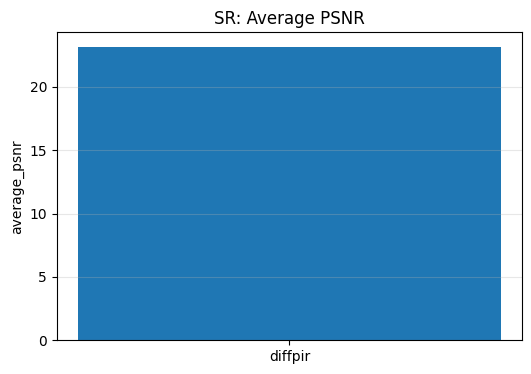

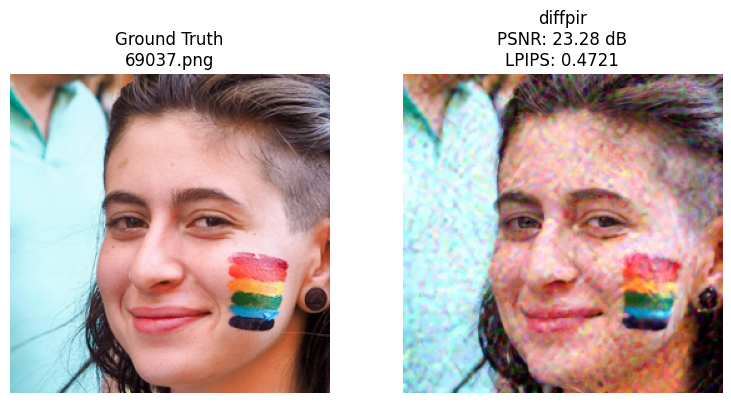

In [6]:
# Super-resolution comparison
sr_results = compare_task(
    task="sr",
    testset_root="testsets/demo_test",
    methods=["diffpir"],  # add "pnp_drunet" once implemented
)
plot_metric_bar(sr_results, metric="average_psnr", title="SR: Average PSNR")
show_results(sr_results)

[2026-03-12 10:49:29,335][diffpir_inpaint.69037][INFO] Starting DiffPIR inpainting | img=69037 | lambda=1.000 | zeta=1.000 | noise=0.0000 | model=diffusion_ffhq_10m


Loading diffpir from configs/inpaint.yaml
MethodConfig(task='inpaint', generate_mode='DiffPIR', lambda_=1.0, zeta=1.0, sf=1, extra={'seed': 42, 'noise_level_img': 0.0, 'noise_level_model': 0.0, 'model_name': 'diffusion_ffhq_10m', 'testset_name': 'demo_test', 'num_train_timesteps': 1000, 'iter_num': 20, 'iter_num_U': 1, 'batch_size': 16, 'save_L': True, 'save_E': True, 'sub_1_analytic': True, 'log_process': False, 'ddim_sample': False, 'model_output_type': 'pred_xstart', 'skip_type': 'quad', 'eta': 0.0, 'guidance_scale': 1.0, 'n_channels': 3, 'cwd': '', 'calc_LPIPS': True, 'beta_start': 0.0001, 'beta_end': 0.02, 'load_mask': False, 'mask_name': 'gt_keep_masks/face/000000.png', 'mask_type': 'random', 'mask_len_range': [128, 129], 'mask_prob_range': [0.5, 0.5]})
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/Users/armandblin/Desktop/DiffPIR/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/armandblin/Desktop/DiffPIR/.venv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
[2026-03-12 10:49:30,899][diffpir_inpaint.69037][INFO] Loading ground-truth image from testsets/demo_test/69037.png
[2026-03-12 10:49:30,921][diffpir_inpaint.69037][INFO] Generated random mask | len_range=[128, 129] | prob_range=[0.5, 0.5]
[2026-03-12 10:49:30,921][diffpir_inpaint.69037][INFO] Applying inpainting mask and A

Loading model from: /Users/armandblin/Desktop/DiffPIR/.venv/lib/python3.11/site-packages/lpips/weights/v0.1/vgg.pth


DiffPIR Inpainting: 100%|██████████| 20/20 [00:15<00:00,  1.33it/s]
[2026-03-12 10:49:46,024][diffpir_inpaint.69037][INFO] Reverse diffusion finished for 69037
[2026-03-12 10:49:46,180][diffpir_inpaint.69037][INFO] Results | img=69037 | PSNR=32.134 dB | LPIPS=0.1096
[2026-03-12 10:49:46,184][diffpir_inpaint.69037][INFO] Saved restored image to outputs/diffpir_inpaint/69037_diffpir.png
[2026-03-12 10:49:46,188][diffpir_inpaint.69037][INFO] Saved masked image to outputs/diffpir_inpaint/69037_masked.png
[2026-03-12 10:49:46,250][diffpir_inpaint.69133][INFO] Starting DiffPIR inpainting | img=69133 | lambda=1.000 | zeta=1.000 | noise=0.0000 | model=diffusion_ffhq_10m


...

DiffPIR Inpainting: 100%|██████████| 20/20 [00:15<00:00,  1.30it/s]
[2026-03-12 10:50:32,818][diffpir_inpaint.69887][INFO] Reverse diffusion finished for 69887
[2026-03-12 10:50:32,966][diffpir_inpaint.69887][INFO] Results | img=69887 | PSNR=32.545 dB | LPIPS=0.0724
[2026-03-12 10:50:32,970][diffpir_inpaint.69887][INFO] Saved restored image to outputs/diffpir_inpaint/69887_diffpir.png
[2026-03-12 10:50:32,975][diffpir_inpaint.69887][INFO] Saved masked image to outputs/diffpir_inpaint/69887_masked.png
[2026-03-12 10:50:33,052][diffpir_inpaint.69929][INFO] Starting DiffPIR inpainting | img=69929 | lambda=1.000 | zeta=1.000 | noise=0.0000 | model=diffusion_ffhq_10m


Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


[2026-03-12 10:50:34,021][diffpir_inpaint.69929][INFO] Loading ground-truth image from testsets/demo_test/69929.png
[2026-03-12 10:50:34,025][diffpir_inpaint.69929][INFO] Generated random mask | len_range=[128, 129] | prob_range=[0.5, 0.5]
[2026-03-12 10:50:34,025][diffpir_inpaint.69929][INFO] Applying inpainting mask and AWGN (σ=0.0000)
[2026-03-12 10:50:34,038][diffpir_inpaint.69929][INFO] Starting reverse diffusion (20 steps, skip_type=quad)


Loading model from: /Users/armandblin/Desktop/DiffPIR/.venv/lib/python3.11/site-packages/lpips/weights/v0.1/vgg.pth


DiffPIR Inpainting: 100%|██████████| 20/20 [00:13<00:00,  1.46it/s]
[2026-03-12 10:50:47,721][diffpir_inpaint.69929][INFO] Reverse diffusion finished for 69929
[2026-03-12 10:50:47,869][diffpir_inpaint.69929][INFO] Results | img=69929 | PSNR=32.729 dB | LPIPS=0.0868
[2026-03-12 10:50:47,872][diffpir_inpaint.69929][INFO] Saved restored image to outputs/diffpir_inpaint/69929_diffpir.png
[2026-03-12 10:50:47,876][diffpir_inpaint.69929][INFO] Saved masked image to outputs/diffpir_inpaint/69929_masked.png


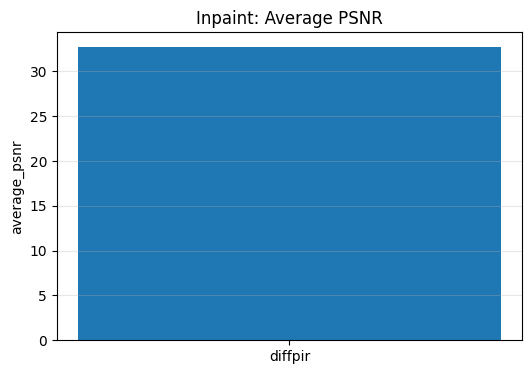

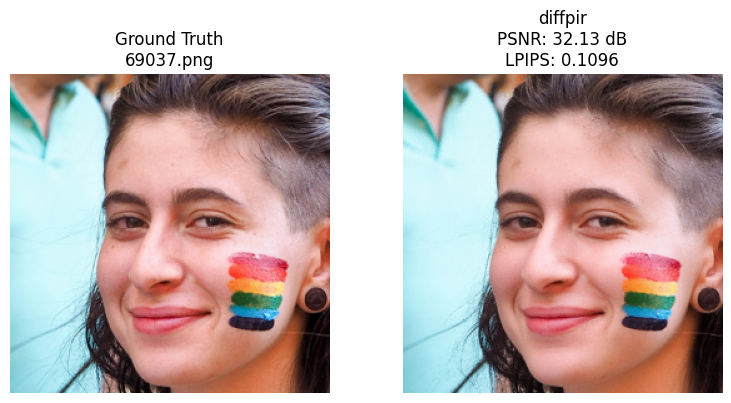

In [ ]:
# Inpainting comparison
inpaint_results = compare_task(
    task="inpaint",
    testset_root="testsets/demo_test",
    methods=["diffpir"],  # "dps_y0", "dps_yt"
)
plot_metric_bar(inpaint_results, metric="average_psnr", title="Inpaint: Average PSNR")
show_results(inpaint_results)